# Measurement Quality of Reported Crypto Market Capitalization — Pilot Walkthrough

**Research question.** Is a meaningful share of reported crypto market capitalization *mechanically* inflated rather than economically supported?

Reported market cap = `price × circulating supply`. Both terms are noisy:

- **Supply side.** Industry free-float adjustments (Coin Metrics, FTSE-style banding) deduct disclosed locked/treasury holdings and band the result coarsely. They rely largely on project-disclosed labels.
- **Price side.** No major industry or academic measure corrects the *price* term for thin liquidity or wash-trading-inflated volume, even though the last-trade price for a thinly traded token does not reflect what would clear at meaningful size.

This pilot focuses on the price side: it builds an illiquidity-adjusted view of reported market capitalization for ~100 ERC-20 tokens and visualizes where the reported figures diverge from liquidity-supported reality.

The full project extends this to the supply side (using direct on-chain reads of vesting contracts and dormant-wallet dormancy rules, stricter than Coin Metrics' banded methodology) and applies event-study methodology from the equity IPO lockup-expiration literature (Ofek & Richardson 2000; Field & Hanka 2001) to scheduled token unlock events on Ethereum.


**Supply-side and unlock-event data infrastructure** is implemented separately in `02_tokenomist_supply_check.ipynb`. That work is feasibility-only on the free-trial data tier and is not part of the headline pilot findings here.

## 0. Setup: CoinGecko API key (optional but recommended)

This cell loads a CoinGecko API key from a local `.env` file in the project root, if present. Without a key the pilot still works but is throttled (~5–15 req/min) and the 100-token pull takes 20+ minutes. With a free Demo key it takes about 4 minutes.

**To set up:** create a file named `.env` in the project root (one level up from `notebooks/`) containing one line:
```
COINGECKO_API_KEY=CG-your-demo-key-here
```

The `.env` file is gitignored, so the key never touches the repo. Get a free Demo key at <https://www.coingecko.com/en/api/pricing>.

In [1]:
import os
from pathlib import Path

# Lightweight .env loader (no python-dotenv dependency required).
env_path = Path('..') / '.env'
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        k, v = line.split('=', 1)
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

key = os.environ.get('COINGECKO_API_KEY', '').strip()
plan = os.environ.get('COINGECKO_PLAN', 'demo').strip().lower()
if key:
    masked = key[:5] + '...' + key[-3:] if len(key) > 10 else '***'
    print(f'CoinGecko key loaded ({plan} plan): {masked}')
else:
    print('No CoinGecko key found. Pilot will use the public endpoint (slow).')
    print('Create a .env file in the project root with COINGECKO_API_KEY=CG-... to speed up.')

CoinGecko key loaded (demo plan): CG-Rh...6W8


## 1. Universe and data pull

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from src import data_fetch, measures, plots

universe = data_fetch.load_universe('../data/tokens.csv')
print(f'{len(universe)} tokens in universe')
universe.head()

101 tokens in universe


,coingecko_id,symbol,notes
0,chainlink,LINK,established large-cap oracle
1,uniswap,UNI,dex governance large-cap
2,aave,AAVE,lending protocol large-cap
3,maker,MKR,mkr governance large-cap
4,the-graph,GRT,infra mid-cap


Pull 365 days of daily OHLCV and market cap from CoinGecko — the maximum the free Demo tier allows. The full project will extend this to the January 2022 onward window using Analyst-tier API access, paid from the grant budget. Results are cached locally for 24 hours, so re-runs are fast after the first.

In [3]:
# This takes ~5 minutes on the first run due to CoinGecko rate limits.
# Subsequent runs load from local cache.
histories = data_fetch.fetch_all(universe, days=365)
print(f'successfully fetched {len(histories)} / {len(universe)} tokens')

  CoinGecko plan: Demo (≤365 days, 30/min, 10K/month)
  effective window: 365 days
[  1/101] LINK       chainlink
[  2/101] UNI        uniswap
[  3/101] AAVE       aave
[  4/101] MKR        maker
[  5/101] GRT        the-graph
[  6/101] CRV        curve-dao-token
[  7/101] SNX        synthetix-network-token
  ! synthetix-network-token: HTTP 404
[  8/101] COMP       compound-governance-token
[  9/101] BAL        balancer
[ 10/101] YFI        yearn-finance
[ 11/101] 1INCH      1inch
[ 12/101] LRC        loopring
[ 13/101] ANKR       ankr
[ 14/101] OCEAN      ocean-protocol
[ 15/101] INJ        injective-protocol
[ 16/101] KNC        kyber-network-crystal
[ 17/101] SUSHI      sushi
[ 18/101] BNT        bancor
[ 19/101] REN        ren
  ! ren: HTTP 404
[ 20/101] BAND       band-protocol
[ 21/101] NMR        numeraire
[ 22/101] STORJ      storj
[ 23/101] TRB        tellor
[ 24/101] POWR       power-ledger
[ 25/101] CVC        civic
[ 26/101] MVL        mass-vehicle-ledger
[ 27/101] POLY    

## 2. Per-token summary statistics

For each token we compute, over a 90-day rolling window:

- **Amihud illiquidity** = mean of `|daily_return| / daily_dollar_volume`. Higher values mean price moves more per dollar traded — the canonical price-impact measure (Amihud 2002).
- **Days to liquidate 1%** = `0.01 × reported_mcap / median_daily_volume`. An intuitive, units-friendly way to read liquidity against reported size.
- **Realized volatility (annualized)** and **max drawdown** as reference outcome variables for the full project.

In [4]:
summary = measures.summarize(histories)
summary.to_csv('../data/panel.csv', index=False)
summary.head(15)

  filtered 2 tokens with mcap < $100,000 or missing measures


,coingecko_id,symbol,mcap_usd,median_daily_volume_usd,amihud_illiq,days_to_liquidate_1pct,realized_vol_ann_90d,max_drawdown_90d,n_obs
0,chainlink,LINK,6.764070e+09,3.543498e+08,0.000070,0.190887,0.745317,-0.350336,365
1,shiba-inu,SHIB,3.604586e+09,1.244052e+08,0.000184,0.289746,0.702568,-0.328705,365
2,bittensor,TAO,2.364198e+09,1.625136e+08,0.000239,0.145477,1.043797,-0.388399,365
3,uniswap,UNI,2.104770e+09,1.889264e+08,0.000135,0.111407,0.870322,-0.380037,365
4,pepe,PEPE,1.596652e+09,3.457074e+08,0.000086,0.046185,1.055390,-0.366880,365
5,aave,AAVE,1.428302e+09,3.390761e+08,0.000092,0.042123,0.936833,-0.437599,365
6,quant-network,QNT,1.068082e+09,1.264994e+07,0.001764,0.844338,0.740057,-0.307031,365
7,render-token,RNDR,9.408507e+08,7.321050e+07,0.000492,0.128513,0.932134,-0.381215,365
8,ethena,ENA,9.346856e+08,1.020852e+08,0.000337,0.091559,1.008331,-0.544783,365
9,worldcoin-wld,WLD,8.699251e+08,8.976725e+07,0.000380,0.096909,1.210196,-0.586804,365


## 3. Figure 1 — Liquidity vs. reported market cap

Plot log(Amihud illiquidity) against log(market cap). In a well-integrated market, larger market cap should correspond to lower illiquidity on average (clear downward slope). Tokens *above* the OLS line have illiquidity higher than their reported size would predict — the quantitative footprint of mechanically-inflated market caps.

The top 10% of residuals are labeled.

  wrote ../figures/fig1_amihud_vs_mcap.png


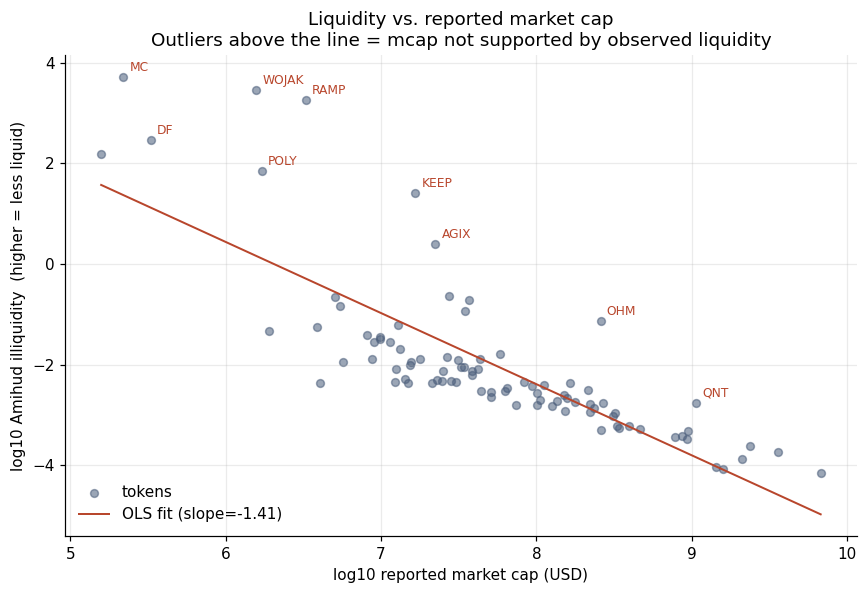

In [5]:
plots.fig1_amihud_vs_mcap(summary, '../figures/fig1_amihud_vs_mcap.png')
from IPython.display import Image
Image('../figures/fig1_amihud_vs_mcap.png')

## 4. Figure 2 — Days to liquidate 1% of market cap, by market-cap decile

If reported market capitalization were well-supported by trading depth, 'days to liquidate 1%' should be roughly stable or scale predictably with market cap (larger markets have proportionally larger volumes). A non-monotonic or concave pattern — with mid-cap tokens taking disproportionately long to liquidate — indicates mechanical inflation of reported market cap at that tier.

  wrote ../figures/fig2_days_to_liquidate_by_decile.png


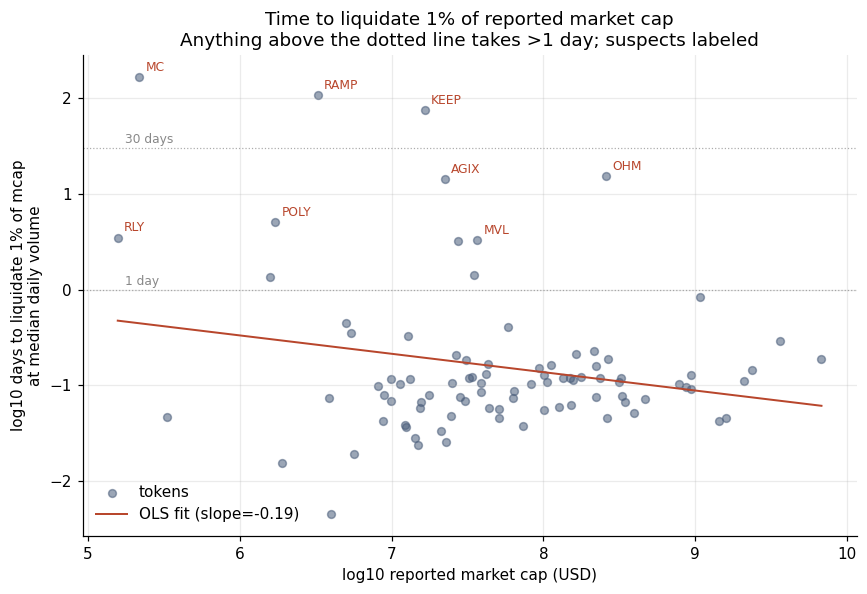

In [6]:
plots.fig2_days_to_liquidate_by_decile(summary, '../figures/fig2_days_to_liquidate_by_decile.png')
Image('../figures/fig2_days_to_liquidate_by_decile.png')

## 5. What this pilot shows, and what it deliberately does not

**Shows.** A defensible, reproducible pipeline for computing liquidity-quality measures and linking them to reported market capitalization. Two descriptive figures that visualize where reported market cap is and is not supported by observed liquidity. With N=90 tokens after data-quality filtering, the cross-sectional pattern is visible at the descriptive level: a strong size-liquidity scaling relationship (slope ≈ -1.4 in log-log Amihud vs. mcap) with a meaningful long tail of mid-cap tokens whose reported capitalization is not supported by observed trading depth.

**Does not show.** Predictive tests. A properly powered causal exercise. The supply-side stricter-than-Coin-Metrics free-float measure. Any unlock event-study results. These are the contribution of the full project, which requires the ~600 hours of work detailed in the research proposal.

**Supply-side / unlock-event infrastructure** is exercised separately in `02_tokenomist_supply_check.ipynb` as a feasibility check. The figures there are illustrative only — small-N feasibility evidence, not findings.

**An earlier N=10 null result.** A prior spot-check using only a disclosed-category supply-side proxy (reported circulating minus disclosed lockups) showed no cross-sectional correlation with realized volatility. This is expected: (i) that proxy is essentially the Coin Metrics adjustment, so there is no reason to expect it to differ from reported mcap in predictive power; (ii) unconditional volatility is the wrong outcome for pre-scheduled supply events — the equity lockup literature finds effects in CARs at the event window, not in average vol; (iii) N=10 is orders of magnitude too small for a powered test. The present pilot focuses on the price-side channel, where the descriptive signal is visible without causal identification.